In [1]:
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

from PGAM.GAM_library import *
from PGAM.gam_data_handlers import *

# ============================================================
# 1. BASIC PARAMETERS
# ============================================================

rng = np.random.default_rng(42)
dt = 0.006                   # 6 ms bins
duration_sec = 600           # 10 minutes
T = int(duration_sec / dt)
time = np.arange(T) * dt
print("Number of bins:", T)

# ============================================================
# 2. SIMULATE ANIMAL POSITION
#
# Here I use a simple 1-D track from 0 to 100 cm.
# The animal repeatedly runs back and forth.
# ============================================================

track_length = 100.0
period = 12.0                # seconds for one back-and-forth cycle
phase = (time % period) / period
position = np.where(
    phase < 0.5,
    2 * phase * track_length,
    2 * (1 - phase) * track_length
)

# small positional noise
position += rng.normal(0, 1.0, T)
position = np.clip(position, 0, track_length)

# ============================================================
# 3. DEFINE A TRUE PLACE FIELD
# ============================================================

place_center = 60.0          # cm
place_sigma = 5.0           # cm
baseline_rate = 0.5          # Hz
peak_rate = 8.0              # additional Hz in field
place_component = peak_rate * np.exp(
    -(position - place_center)**2 /
    (2 * place_sigma**2)
)
true_rate_without_history = baseline_rate + place_component


Number of bins: 100000


Number of simulated spikes: 920
Mean firing rate: 1.5333333333333334 Hz
True log-history kernel: [0.6        0.30805027 0.15815828 0.08120117 0.04169007]


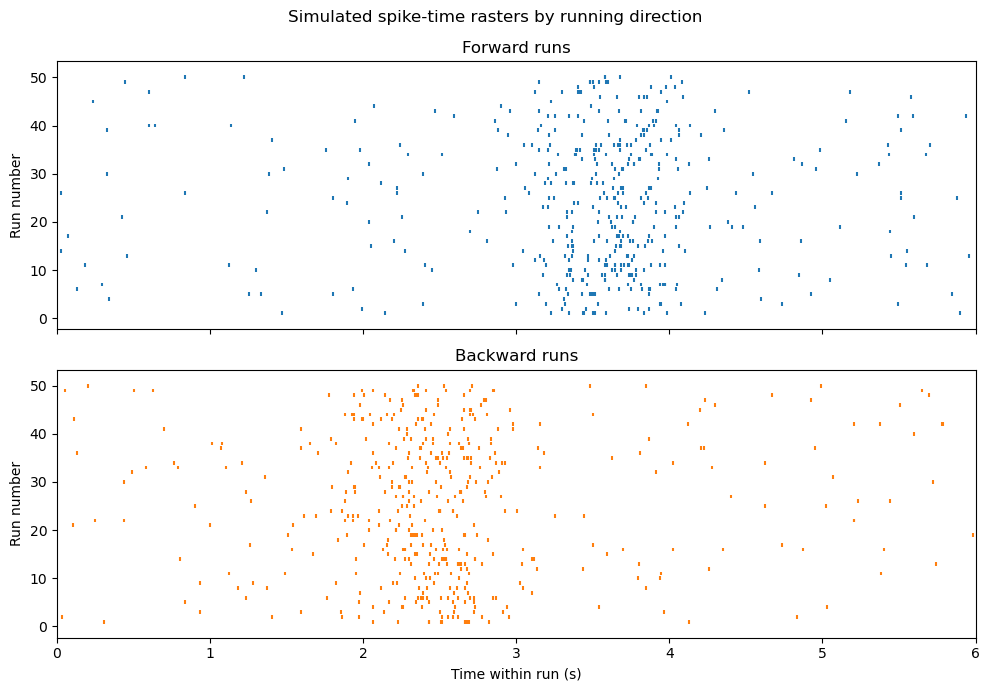

Text(0.5, 1.0, 'Simulated Firing Rate With and Without History')

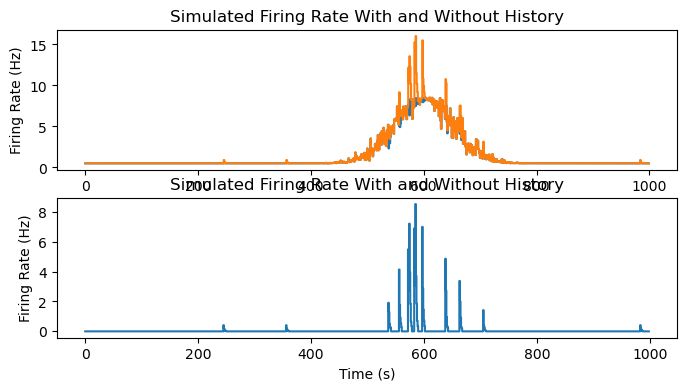

In [3]:
# ============================================================
# 4. SIMULATE A POISSON PLACE CELL WITH SPIKE TIMES
#
# The neuron has a position-dependent Poisson intensity. A spike event
# is generated in continuous time within each 6-ms bin. The binned array
# spk is retained as the response representation required by PGAM.
# ============================================================

# Each previous spike adds an exponentially decaying effect on log firing
# rate for five bins. After five bins its contribution is zero.
history_duration_bins = 5
history_decay_bins = 1.5
history_log_amplitude = 0.6
history_lags = np.arange(history_duration_bins)
h_true = history_log_amplitude * np.exp(
    -history_lags / history_decay_bins
)

n_history_bins = len(h_true)
spk = np.zeros(T, dtype=int)
spike_times_sec = []
true_rate_with_history = np.zeros(T, dtype=float)

for t in range(T):
    # Previous spikes affect the current log intensity, so the simulation is causal.
    n_lags = min(t, n_history_bins)
    history_effect = np.dot(
        h_true[:n_lags],
        spk[t - n_lags:t][::-1]
    )

    rate_hz = true_rate_without_history[t] * np.exp(history_effect)
    mu = rate_hz * dt
    n_spikes = rng.poisson(mu)

    # Draw event times uniformly within this bin. This is the event-time
    # representation of a piecewise-constant Poisson process.
    if n_spikes > 0:
        spike_times_sec.extend(
            time[t] + rng.uniform(0, dt, size=n_spikes)
        )

    spk[t] = n_spikes
    true_rate_with_history[t] = rate_hz

spike_times_sec = np.asarray(spike_times_sec)

print("Number of simulated spikes:", spike_times_sec.size)
print("Mean firing rate:", spike_times_sec.size / duration_sec, "Hz")
print("True log-history kernel:", h_true)

# Align each spike to its run and split each run into forward/backward halves.
half_period = period / 2
n_runs = int(np.ceil(duration_sec / period))
run_indices = np.floor(spike_times_sec / period).astype(int)
within_run_time = spike_times_sec - run_indices * period

forward_spikes_by_run = []
backward_spikes_by_run = []
for run_idx in range(n_runs):
    run_spikes = within_run_time[run_indices == run_idx]
    forward_spikes_by_run.append(run_spikes[run_spikes < half_period])
    backward_spikes_by_run.append(
        run_spikes[run_spikes >= half_period] - half_period
    )

# Plot one raster row for every forward and backward run.
fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
axes[0].eventplot(
    forward_spikes_by_run,
    lineoffsets=np.arange(1, n_runs + 1),
    linelengths=0.8
)
axes[0].set_title("Forward runs")
axes[0].set_ylabel("Run number")
axes[0].set_xlim(0, half_period)

axes[1].eventplot(
    backward_spikes_by_run,
    lineoffsets=np.arange(1, n_runs + 1),
    linelengths=0.8,
    colors="tab:orange"
)
axes[1].set_title("Backward runs")
axes[1].set_xlabel("Time within run (s)")
axes[1].set_ylabel("Run number")
axes[1].set_xlim(0, half_period)

fig.suptitle("Simulated spike-time rasters by running direction")
fig.tight_layout()
plt.show()


plt.figure(figsize=(8, 4))
plt.subplot(2, 1, 1)
plt.plot(true_rate_without_history[:1000], drawstyle='steps-mid', label='Without history')
plt.plot(true_rate_with_history[:1000], drawstyle='steps-mid', label='With history')
plt.xlabel("Time (s)")
plt.ylabel("Firing Rate (Hz)")
plt.title("Simulated Firing Rate With and Without History") 

plt.subplot(2, 1, 2)

plt.plot(true_rate_with_history[1:1000]-true_rate_without_history[1:1000], drawstyle='steps-mid', label='Without history')
plt.xlabel("Time (s)")
plt.ylabel("Firing Rate (Hz)")
plt.title("Simulated Firing Rate With and Without History") 


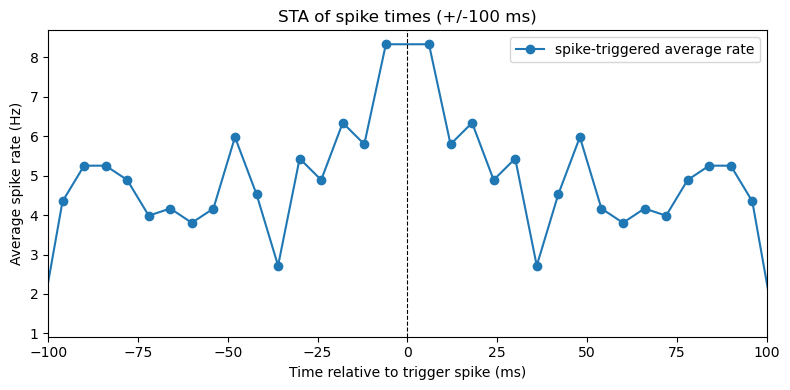

STA trigger events: 920


In [4]:
# ============================================================
# 5. SPIKE-TRIGGERED AVERAGE OF SPIKE TIMES
# ============================================================

sta_window_sec = 0.100
sta_bin_width_sec = dt
sta_half_bins = int(round(sta_window_sec / sta_bin_width_sec))
sta_half_window_sec = sta_half_bins * sta_bin_width_sec

# Use every simulated event as a trigger, excluding edge events that do not
# have a complete +/-100 ms window around them.
sta_triggers = spike_times_sec[
    (spike_times_sec >= sta_half_window_sec)
    & (spike_times_sec <= duration_sec - sta_half_window_sec)
]

# Bin edges are centered on multiples of dt, including a zero-lag bin.
sta_edges_sec = np.arange(
    -sta_half_window_sec - sta_bin_width_sec / 2,
    sta_half_window_sec + sta_bin_width_sec,
    sta_bin_width_sec
)
sta_centers_sec = (sta_edges_sec[:-1] + sta_edges_sec[1:]) / 2

triggered_relative_times_sec = []
for trigger_time in sta_triggers:
    start = np.searchsorted(
        spike_times_sec,
        trigger_time - sta_half_window_sec,
        side='left'
    )
    stop = np.searchsorted(
        spike_times_sec,
        trigger_time + sta_half_window_sec,
        side='right'
    )
    triggered_relative_times_sec.append(
        spike_times_sec[start:stop] - trigger_time
    )

all_triggered_relative_times_sec = np.concatenate(triggered_relative_times_sec)
sta_counts = np.histogram(
    all_triggered_relative_times_sec,
    bins=sta_edges_sec
)[0]
sta_rate_hz = sta_counts / (len(sta_triggers) * sta_bin_width_sec)
sta_lags_ms = sta_centers_sec * 1000

# Remove the zero-lag bin containing the trigger event itself.
sta_plot_mask = ~np.isclose(sta_centers_sec, 0.0)

plt.figure(figsize=(8, 4))
plt.plot(
    sta_lags_ms[sta_plot_mask],
    sta_rate_hz[sta_plot_mask],
    'o-',
    linewidth=1.5,
    label='spike-triggered average rate'
)
plt.axvline(0, color='black', linestyle='--', linewidth=0.8)
plt.xlabel('Time relative to trigger spike (ms)')
plt.ylabel('Average spike rate (Hz)')
plt.title('STA of spike times (+/-100 ms)')
plt.xlim(-100, 100)
plt.legend()
plt.tight_layout()
plt.show()

print("STA trigger events:", len(sta_triggers))

In [5]:

# ============================================================
# 7. CREATE PGAM SMOOTH HANDLER
# ============================================================

sm_handler = smooths_handler()
hist_input = spk.astype(float, copy=True)
assert np.array_equal(hist_input, spk)
# ============================================================
# 8. ADD POSITION SMOOTH
#
# 1-D place field for this example.
# ============================================================

ord_place = 4
n_place_knots = 12
internal_knots = np.linspace(
    0,
    track_length,
    n_place_knots
)

place_knots = np.hstack((
    [internal_knots[0]] * (ord_place - 1),
    internal_knots,
    [internal_knots[-1]] * (ord_place - 1)
))


sm_handler.add_smooth(
    'position',
    [position],
    ord=4,
    knots=[place_knots],
    is_cyclic=[False],
    penalty_type='der',
    der=2,
    is_temporal_kernel=False,
    lam=10
)



True

In [6]:
# ============================================================
# 9. ADD SELF-HISTORY SMOOTH
#
# We want approximately:
#
# 6, 12, 18, 24, 30, 36 ms
#
# PGAM uses kernel_direction=1 for a causal effect after an event.
# Six causal lags therefore need six samples after the event anchor.
# ============================================================

kernel_length = 2 * n_history_bins + 1
sm_handler.add_smooth(
    'self_history',
    [hist_input],
    ord=2,
    knots_num=n_history_bins,
    penalty_type='diff',
    der=2,
    is_temporal_kernel=True,
    kernel_direction=1,
    kernel_length=kernel_length,
    trial_idx=np.ones(T, dtype=int),
    time_bin=dt,
    event_input=True,
    lam=10
)

True

In [ ]:
# ============================================================
# 10. CHECK MODEL TERMS
# ============================================================

print("\nModel smooths:")
print(sm_handler.smooths_var)

# ============================================================
# 11. DEFINE POISSON MODEL
# ============================================================

link = deriv3_link(
    sm.genmod.families.links.log()
)

poissFam = sm.genmod.families.family.Poisson(
    link=link
)

# ============================================================
# 12. CREATE PGAM MODEL
# ============================================================

gam_model = general_additive_model(
    sm_handler,
    sm_handler.smooths_var,
    spk,
    poissFam,
    fisher_scoring=False
)


# ============================================================
# 13. FIT COMPARISON MODELS
#
# position_only is the reduced baseline: it cannot explain bursts.
# full includes position and causal self-history, so its position
# smooth is estimated after accounting for burst-driven spikes.
# ============================================================

fit_options = dict(
    max_iter=300,
    tol=1e-6,
    conv_criteria='deviance',
    method='L-BFGS-B',
    gcv_sel_tol=1e-8,
    use_dgcv=True,
    fit_initial_beta=True
)

full = gam_model.optim_gam(
    ['position', 'self_history'],
    **fit_options
)

position_only = gam_model.optim_gam(
    ['position'],
    **fit_options
)


# ============================================================
# 14. PRINT RESULTS
# ============================================================

print("\nFit complete")
print("Full model terms:", full.var_list)
print("Position-only terms:", position_only.var_list)


Model smooths:
['position', 'self_history']
3rd order deriv of link function is ok!
4th order deriv of link function is ok!
RUNNING THE L-BFGS-B CODE

           * * *

Machine precision = 2.220D-16
 N =           18     M =           10

At X0         0 variables are exactly at the bounds

At iterate    0    f=  1.00012D+05    |proj g|=  9.90800D+04

At iterate    1    f=  3.77189D+04    |proj g|=  3.58682D+04

At iterate    2    f=  2.23086D+04    |proj g|=  1.99380D+04

At iterate    3    f=  1.23494D+04    |proj g|=  9.33161D+03

At iterate    4    f=  8.14654D+03    |proj g|=  4.56526D+03

At iterate    5    f=  6.19822D+03    |proj g|=  2.08780D+03

At iterate    6    f=  5.42068D+03    |proj g|=  8.79744D+02

At iterate    7    f=  5.12638D+03    |proj g|=  2.85734D+02

At iterate    8    f=  4.98639D+03    |proj g|=  1.79329D+02

At iterate    9    f=  4.83964D+03    |proj g|=  1.86042D+02

At iterate   10    f=  4.62262D+03    |proj g|=  1.70947D+02

At iterate   11    f=  4.

 This problem is unconstrained.



At iterate   43    f=  4.56633D+03    |proj g|=  7.19200D-02

At iterate   44    f=  4.56633D+03    |proj g|=  1.85631D-01

At iterate   45    f=  4.56633D+03    |proj g|=  5.16514D-02

At iterate   46    f=  4.56633D+03    |proj g|=  3.67122D-02

At iterate   47    f=  4.56633D+03    |proj g|=  7.91047D-02

At iterate   48    f=  4.56633D+03    |proj g|=  2.85004D-02

           * * *

Tit   = total number of iterations
Tnf   = total number of function evaluations
Tnint = total number of segments explored during Cauchy searches
Skip  = number of BFGS updates skipped
Nact  = number of active bounds at final generalized Cauchy point
Projg = norm of the final projected gradient
F     = final function value

           * * *

   N    Tit     Tnf  Tnint  Skip  Nact     Projg        F
   18     48     54      1     0     0   2.850D-02   4.566D+03
  F =   4566.3323771442983     

CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH             
RUNNING THE L-BFGS-B CODE

           * * *

Machin

 This problem is unconstrained.


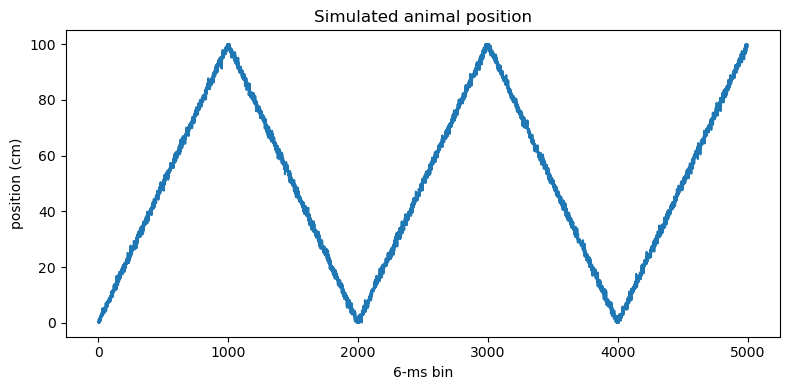

In [8]:

# ============================================================
# 15. PLOT THE SIMULATED PLACE FIELD
# ============================================================

plt.figure(figsize=(8, 4))

plt.plot(
    position[:5000],
    label='position'
)

plt.xlabel("6-ms bin")
plt.ylabel("position (cm)")
plt.title("Simulated animal position")
plt.tight_layout()
plt.show()



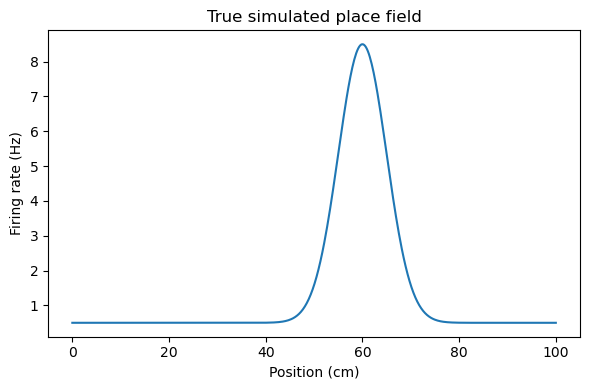

In [9]:

# ============================================================
# 16. PLOT TRUE SPATIAL FIRING RATE
# ============================================================

xx = np.linspace(0, track_length, 500)

true_place_rate = (
    baseline_rate
    +
    peak_rate * np.exp(
        -(xx - place_center)**2 /
        (2 * place_sigma**2)
    )
)

plt.figure(figsize=(6, 4))

plt.plot(
    xx,
    true_place_rate
)

plt.xlabel("Position (cm)")
plt.ylabel("Firing rate (Hz)")
plt.title("True simulated place field")
plt.tight_layout()
plt.show()



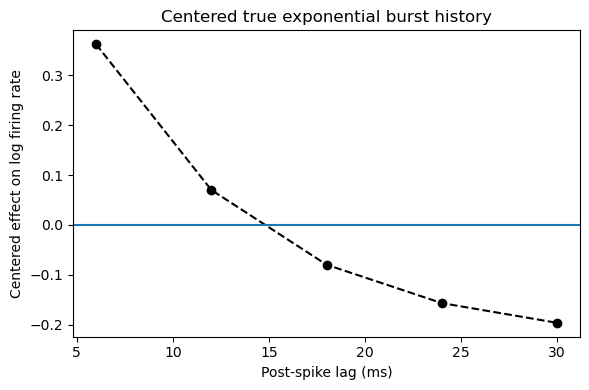

In [10]:
# ============================================================
# 17. SHOW TRUE HISTORY KERNEL USED FOR SIMULATION
# ============================================================

lags_ms = np.arange(
    1,
    n_history_bins + 1
) * dt * 1000

# PGAM centers smooth effects, so center the simulated log-history kernel
# before comparing it with the fitted history smooth.
true_history_effect = h_true - h_true.mean()

plt.figure(figsize=(6, 4))
plt.plot(
    lags_ms,
    true_history_effect,
    'k--',
    marker='o'
)
plt.axhline(0)
plt.xlabel("Post-spike lag (ms)")
plt.ylabel("Centered effect on log firing rate")
plt.title("Centered true exponential burst history")
plt.tight_layout()
plt.show()

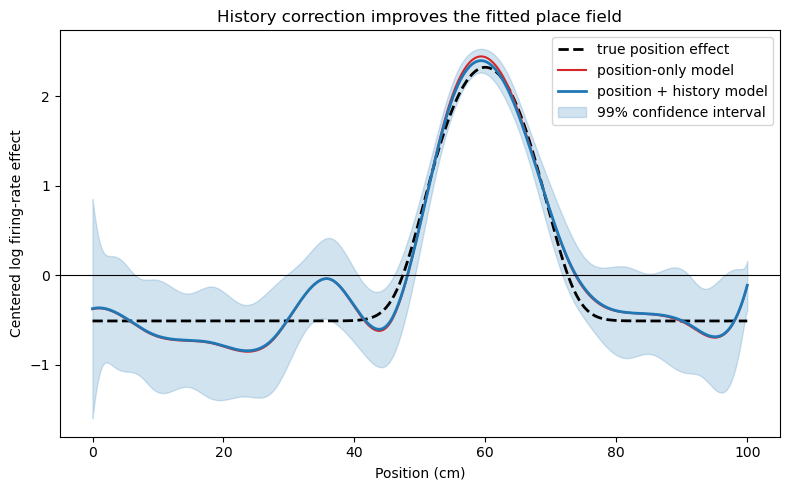

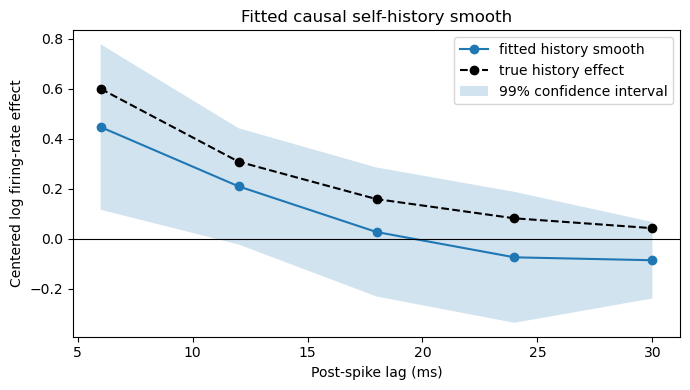

In [13]:
# ============================================================
# 18. COMPARE FITTED POSITION SMOOTHES
# ============================================================

position_grid = np.linspace(0, track_length, 500)

full_position_fit, full_position_lower, full_position_upper = (
    full.smooth_compute(
        [position_grid],
        'position',
        0.99
    )
)

position_only_fit, _, _ = position_only.smooth_compute(
    [position_grid],
    'position',
    0.99
)

# smooth_compute returns centered log-rate effects, so center the truth
# before comparing it with the fitted curves.
true_position_effect = (
    np.log(
        baseline_rate
        + peak_rate * np.exp(
            -(position_grid - place_center)**2 /
            (2 * place_sigma**2)
        )
    )
)
true_position_effect -= true_position_effect.mean()

plt.figure(figsize=(8, 5))
plt.plot(
    position_grid,
    true_position_effect,
    'k--',
    linewidth=2,
    label='true position effect'
)
plt.plot(
    position_grid,
    position_only_fit,
    color='tab:red',
    label='position-only model'
)
plt.plot(
    position_grid,
    full_position_fit,
    color='tab:blue',
    linewidth=2,
    label='position + history model'
)
plt.fill_between(
    position_grid,
    full_position_lower,
    full_position_upper,
    color='tab:blue',
    alpha=0.2,
    label='99% confidence interval'
)
plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel('Position (cm)')
plt.ylabel('Centered log firing-rate effect')
plt.title('History correction improves the fitted place field')
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# 19. PLOT FITTED SELF-HISTORY SMOOTH
# ============================================================

history_basis_length = full.smooth_info['self_history']['basis_kernel'].shape[0]
history_impulse = np.zeros(history_basis_length)
history_impulse[(history_basis_length - 1) // 2] = 1
history_fit, history_lower, history_upper = full.smooth_compute(
    [history_impulse],
    'self_history',
    0.99
)

history_lags_ms = (
    np.arange(history_basis_length)
    - (history_basis_length - 1) // 2
) * dt * 1000

# A causal kernel occupies positive relative lags.
history_mask = history_lags_ms > 0

plt.figure(figsize=(7, 4))
plt.plot(
    history_lags_ms[history_mask],
    history_fit[history_mask],
    'o-',
    label='fitted history smooth'
)
plt.plot(
    lags_ms,
    h_true,
    'k--',
    marker='o',
    label='true history effect'
)
plt.fill_between(
    history_lags_ms[history_mask],
    history_lower[history_mask],
    history_upper[history_mask],
    alpha=0.2,
    label='99% confidence interval'
)
plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel('Post-spike lag (ms)')
plt.ylabel('Centered log firing-rate effect')
plt.title('Fitted causal self-history smooth')
plt.legend()
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'History correction improves the fitted place field')

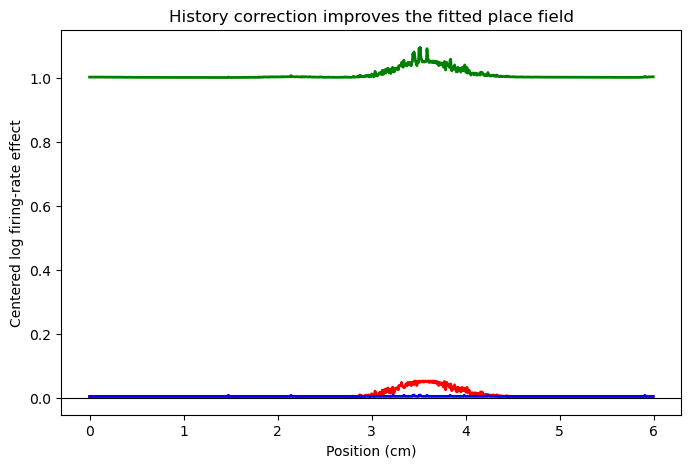

In [ ]:




full_position, _, _ = full.smooth_compute(
        [position],
        'position',
        0.99
    )
full_position = np.exp(full.beta[0] + full_position)

full_hist, _, _ = full.smooth_compute(
        [hist_input],
        'self_history',
        0.99
    )
full_hist = np.exp(full.beta[0] + full_hist)

full_spike_rate = full.predict([[position], [hist_input]], var_list=full.var_list)
full_spike_rate = np.exp(full.beta[0] + full_spike_rate)




plt.figure(figsize=(8, 5))
plt.plot(
    time[:1000],
    full_position[:1000],
    color='red',
    linewidth=2,
    label='position model'
)

plt.plot(
    time[:1000],
    full_hist[:1000],
    color='blue',
    linewidth=2,
    label='history model'
)

plt.plot(
    time[:1000],
    full_spike_rate[:1000],
    color='green',
    linewidth=2,
    label='position + history model'
)





plt.axhline(0, color='black', linewidth=0.8)
plt.xlabel('Position (cm)')
plt.ylabel('Centered log firing-rate effect')
plt.title('History correction improves the fitted place field')     

